# Model Compression: Pruning, Quantisation, and SC-Aware Sparsity

**SC-NeuroCore v3.14** — Deploy smaller, faster, cheaper.

Neural network compression reduces model size for edge deployment.
SC-NeuroCore provides three compression axes plus an SC-native
pruning method that scores weights by their bitstream contribution.

1. **Magnitude pruning** — zero out weights below threshold
2. **Stochastic pruning** — SC-specific: score by bitstream impact
3. **Quantisation sweep** — 2-bit through 16-bit fixed-point
4. **Combined** — prune + quantise for maximum compression

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.compression.pruning import (
    prune_weights,
    prune_stochastic,
)
from sc_neurocore.compression.quantization import quantize_weights

print("SC-NeuroCore compression demo")

SC-NeuroCore compression demo


## 1. Reference Network

A 3-layer weight set (784→256→64→10) simulating an MNIST
classifier. We measure accuracy as cosine similarity between
compressed and original forward-pass outputs.

In [2]:
rng = np.random.default_rng(42)

weights = [
    rng.standard_normal(size=(256, 784)).astype(np.float32) * np.sqrt(2 / 784),
    rng.standard_normal(size=(64, 256)).astype(np.float32) * np.sqrt(2 / 256),
    rng.standard_normal(size=(10, 64)).astype(np.float32) * np.sqrt(2 / 64),
]

total_params = sum(w.size for w in weights)
print(f"Total parameters: {total_params:,}")
for i, w in enumerate(weights):
    print(f"  Layer {i}: {w.shape} ({w.size:,} params, "
          f"|w| range [{np.abs(w).min():.4f}, {np.abs(w).max():.4f}])")


def eval_accuracy(w_list, x_test=None):
    """Proxy accuracy: cosine similarity of outputs vs reference."""
    if x_test is None:
        x_test = rng.standard_normal(size=(100, 784)).astype(np.float32)
    # Reference forward pass
    y_ref = x_test.copy()
    for W in weights:
        y_ref = np.maximum(0, y_ref @ W.T)  # ReLU
    # Compressed forward pass
    y_comp = x_test.copy()
    for W in w_list:
        y_comp = np.maximum(0, y_comp @ W.T)
    # Cosine similarity
    dots = np.sum(y_ref * y_comp, axis=1)
    norms = np.linalg.norm(y_ref, axis=1) * np.linalg.norm(y_comp, axis=1)
    norms = np.maximum(norms, 1e-8)
    return float(np.mean(dots / norms))


x_test = rng.standard_normal(size=(100, 784)).astype(np.float32)
baseline = eval_accuracy(weights, x_test)
print(f"\nBaseline similarity: {baseline:.6f}")

Total parameters: 217,728
  Layer 0: (256, 784) (200,704 params, |w| range [0.0000, 0.2529])
  Layer 1: (64, 256) (16,384 params, |w| range [0.0000, 0.3615])
  Layer 2: (10, 64) (640 params, |w| range [0.0000, 0.5238])



Baseline similarity: 1.000000


## 2. Magnitude Pruning

In [3]:
thresholds = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
mag_sparsity = []
mag_accuracy = []

for thresh in thresholds:
    pruned, report = prune_weights(weights, threshold=thresh, method="magnitude")
    acc = eval_accuracy(pruned, x_test)
    mag_sparsity.append(report.sparsity)
    mag_accuracy.append(acc)
    print(f"  threshold={thresh:.3f}  sparsity={report.sparsity:.1%}  "
          f"similarity={acc:.4f}")

  threshold=0.001  sparsity=1.6%  similarity=1.0000


  threshold=0.005  sparsity=7.6%  similarity=0.9995
  threshold=0.010  sparsity=15.2%  similarity=0.9968


  threshold=0.020  sparsity=29.8%  similarity=0.9797
  threshold=0.050  sparsity=65.8%  similarity=0.7851


  threshold=0.100  sparsity=93.5%  similarity=0.4620
  threshold=0.150  sparsity=98.9%  similarity=0.3734


  threshold=0.200  sparsity=99.7%  similarity=0.3889


## 3. SC-Aware Stochastic Pruning

SC-specific: weights are scored by their contribution to the
bitstream dot product. A weight $w=0.01$ at bitstream length
$L=256$ produces $\sim 2.5$ expected 1-bits — barely above
noise. Stochastic pruning removes these low-contribution weights.

In [4]:
sc_lengths = [64, 128, 256, 512, 1024]
sc_sparsity = []
sc_accuracy = []

for L in sc_lengths:
    pruned, report = prune_stochastic(weights, bitstream_length=L)
    acc = eval_accuracy(pruned, x_test)
    sc_sparsity.append(report.sparsity)
    sc_accuracy.append(acc)
    print(f"  L={L:5d}  sparsity={report.sparsity:.1%}  "
          f"similarity={acc:.4f}")

  L=   64  sparsity=23.5%  similarity=0.9895


  L=  128  sparsity=11.8%  similarity=0.9984


  L=  256  sparsity=6.0%  similarity=0.9998


  L=  512  sparsity=3.0%  similarity=1.0000


  L= 1024  sparsity=1.5%  similarity=1.0000


## 4. Quantisation Sweep

In [5]:
bit_widths = [2, 3, 4, 6, 8, 12, 16]
quant_accuracy = []
quant_compression = []  # ratio vs 32-bit

for bits in bit_widths:
    q_weights = quantize_weights(weights, bits=bits)
    # Dequantise for eval (simulate fixed-point arithmetic)
    deq = [w.astype(np.float32) for w in q_weights]
    acc = eval_accuracy(deq, x_test)
    ratio = 32.0 / bits
    quant_accuracy.append(acc)
    quant_compression.append(ratio)
    print(f"  {bits:2d}-bit  compression={ratio:.1f}×  similarity={acc:.4f}")

   2-bit  compression=16.0×  similarity=0.3327


   3-bit  compression=10.7×  similarity=0.7081


   4-bit  compression=8.0×  similarity=0.9101


   6-bit  compression=5.3×  similarity=0.9932


   8-bit  compression=4.0×  similarity=0.9994
  12-bit  compression=2.7×  similarity=1.0000


  16-bit  compression=2.0×  similarity=1.0000


## 5. Pareto Frontiers

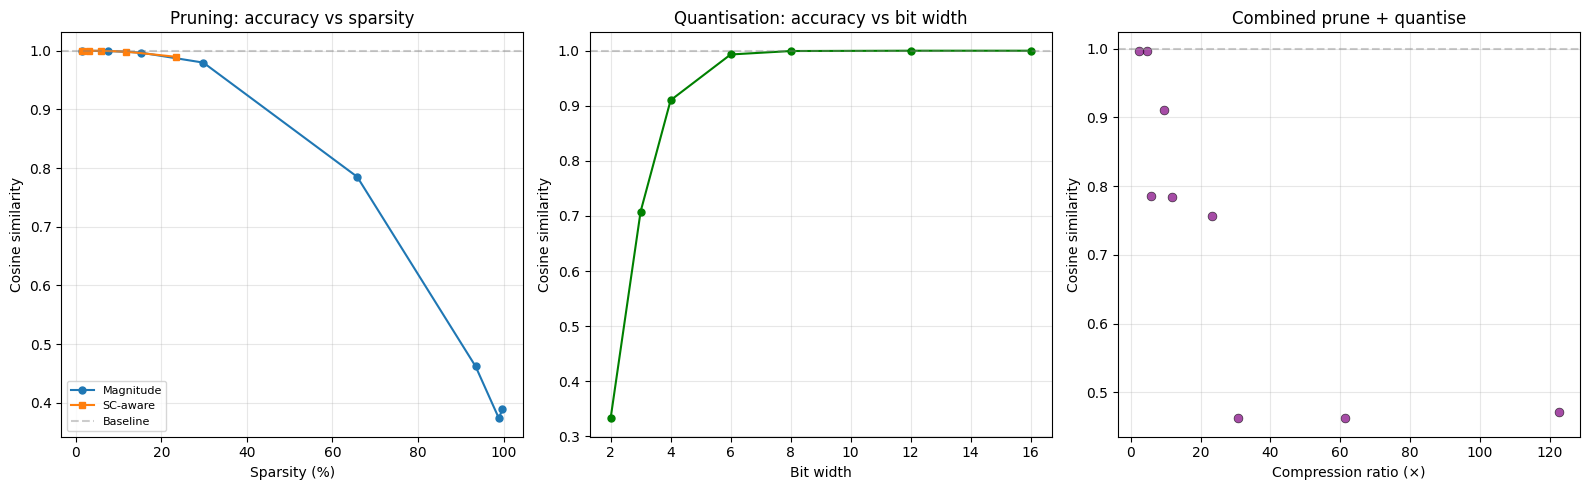

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pruning: sparsity vs accuracy
axes[0].plot([s * 100 for s in mag_sparsity], mag_accuracy, "o-",
             markersize=5, label="Magnitude")
axes[0].plot([s * 100 for s in sc_sparsity], sc_accuracy, "s-",
             markersize=5, label="SC-aware")
axes[0].axhline(baseline, color="gray", linestyle="--", alpha=0.4, label="Baseline")
axes[0].set_xlabel("Sparsity (%)")
axes[0].set_ylabel("Cosine similarity")
axes[0].set_title("Pruning: accuracy vs sparsity")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Quantisation: bits vs accuracy
axes[1].plot(bit_widths, quant_accuracy, "o-", markersize=5, color="green")
axes[1].axhline(baseline, color="gray", linestyle="--", alpha=0.4)
axes[1].set_xlabel("Bit width")
axes[1].set_ylabel("Cosine similarity")
axes[1].set_title("Quantisation: accuracy vs bit width")
axes[1].grid(True, alpha=0.3)

# Combined: compression ratio vs accuracy
combined_ratios = []
combined_accuracy = []
for thresh in [0.01, 0.05, 0.1]:
    for bits in [4, 8, 16]:
        pruned, report = prune_weights(weights, threshold=thresh)
        q_pruned = quantize_weights(pruned, bits=bits)
        deq = [w.astype(np.float32) for w in q_pruned]
        acc = eval_accuracy(deq, x_test)
        # Compression: sparsity * bit reduction
        remaining = 1.0 - report.sparsity
        ratio = 1.0 / (remaining * bits / 32)
        combined_ratios.append(ratio)
        combined_accuracy.append(acc)

axes[2].scatter(combined_ratios, combined_accuracy, s=40, alpha=0.7,
                c="purple", edgecolors="black", linewidth=0.5)
axes[2].axhline(baseline, color="gray", linestyle="--", alpha=0.4)
axes[2].set_xlabel("Compression ratio (×)")
axes[2].set_ylabel("Cosine similarity")
axes[2].set_title("Combined prune + quantise")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Method | Compression | Accuracy impact | FPGA benefit |
|--------|-------------|----------------|--------------|
| Magnitude prune | 50-90% sparsity | Minimal up to ~70% | Fewer synapses, less BRAM |
| SC-aware prune | Depends on L | SC-optimal removal | Fewer AND gates |
| Quantisation (8-bit) | 4× vs float32 | Negligible | Narrower datapaths |
| Quantisation (4-bit) | 8× vs float32 | Small | Half-width multipliers |
| Combined (prune 70% + 4-bit) | 20-30× | Moderate | Minimal footprint |

The SC-aware pruning is novel to SC-NeuroCore: it removes weights
whose bitstream contribution falls below the noise floor at the
target bitstream length. This is more aggressive than magnitude
pruning because it accounts for the encoding resolution.